# SolarSense — Solar Panel Performance Anomaly Detection
### End-to-end prototype: synthetic data → weather-adjusted expected-generation model → anomaly detection → 7-day forecast → maintenance-priority dashboard


## 1. Setup

In [23]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
np.random.seed(42)

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## 2. Generate a synthetic dataset


In [24]:

sites = {
    'Site_A': {'capacity_kw': 50, 'fault': None},
    'Site_B': {'capacity_kw': 80, 'fault': 'gradual_soiling'},
    'Site_C': {'capacity_kw': 65, 'fault': 'sudden_inverter'},
    'Site_D': {'capacity_kw': 40, 'fault': None},
    'Site_E': {'capacity_kw': 100, 'fault': 'partial_shading'},
}

n_days = 365
dates = pd.date_range('2025-01-01', periods=n_days, freq='D')

def make_weather(n_days):
    day_of_year = np.arange(n_days)
    # seasonal irradiance curve (kWh/m2/day), peaks in summer, dips in winter
    seasonal = 5.5 + 3.2 * np.sin(2 * np.pi * (day_of_year - 80) / 365)
    cloud_cover = np.clip(np.random.beta(2, 4, n_days), 0, 1)  # 0=clear,1=overcast
    irradiance = np.clip(seasonal * (1 - 0.75 * cloud_cover) + np.random.normal(0, 0.25, n_days), 0.2, None)
    temperature = 22 + 10 * np.sin(2 * np.pi * (day_of_year - 60) / 365) + np.random.normal(0, 2, n_days)
    return irradiance, cloud_cover, temperature

irr, cloud, temp = make_weather(n_days)

records = []
for site, cfg in sites.items():
    cap = cfg['capacity_kw']
    fault = cfg['fault']
    # physical model: generation scales with irradiance, mildly de-rates with high temp,
    # small panel-age degradation (~0.5%/year), plus noise
    age_degradation = 1 - 0.005 * (np.arange(n_days) / 365)
    temp_derate = 1 - 0.004 * np.clip(temp - 25, 0, None)  # panels lose efficiency above 25C
    base_gen = cap * irr * 0.85 * age_degradation * temp_derate
    noise = np.random.normal(0, base_gen * 0.03)
    generation = np.clip(base_gen + noise, 0, None)

    fault_multiplier = np.ones(n_days)
    if fault == 'gradual_soiling':
        start = 200
        decline = np.clip((np.arange(n_days) - start) / 90, 0, 1) * 0.30  # ramps to -30%
        fault_multiplier -= decline
    elif fault == 'sudden_inverter':
        start, end = 260, 278
        fault_multiplier[start:end] *= 0.35  # sudden ~65% drop
    elif fault == 'partial_shading':
        start = 150
        fault_multiplier[start:] *= 0.88  # steady ~12% drop from that point on

    generation = generation * fault_multiplier

    for i in range(n_days):
        records.append({
            'date': dates[i], 'site': site, 'capacity_kw': cap,
            'irradiance': irr[i], 'cloud_cover': cloud[i], 'temperature': temp[i],
            'generation_kwh': generation[i],
        })

df = pd.DataFrame.from_records(records)
df.to_csv('solar_generation.csv', index=False)
print(df.shape)
df.head()


(1825, 7)


,date,site,capacity_kw,irradiance,cloud_cover,temperature,generation_kwh
0,2025-01-01,Site_A,50,1.76,0.41,12.32,74.71
1,2025-01-02,Site_A,50,2.38,0.30,12.47,96.04
2,2025-01-03,Site_A,50,1.27,0.47,14.19,55.85
3,2025-01-04,Site_A,50,2.26,0.19,15.21,93.69
4,2025-01-05,Site_A,50,1.25,0.65,13.39,53.53


## 3. Quick look at raw generation (weather noise makes faults hard to see by eye)

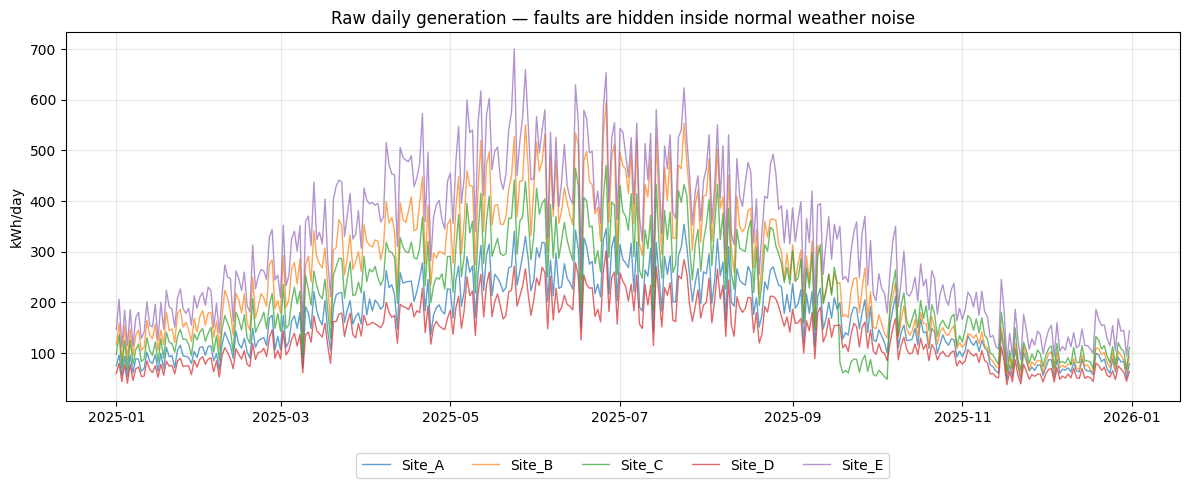

In [25]:

fig, ax = plt.subplots(figsize=(12, 5))
for site in sites:
    sub = df[df.site == site]
    ax.plot(sub.date, sub.generation_kwh, label=site, alpha=0.7, linewidth=1)
ax.set_title('Raw daily generation — faults are hidden inside normal weather noise')
ax.set_ylabel('kWh/day')
ax.legend(ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.12))
plt.tight_layout()
plt.savefig('01_raw_generation.png', dpi=110)
plt.show()


## 4. Build the weather-normalized "expected generation" baseline


In [26]:

BASELINE_DAYS = 90
models, baseline_metrics = {}, {}

for site in sites:
    sub = df[df.site == site].reset_index(drop=True)
    train = sub.iloc[:BASELINE_DAYS]
    X_train = train[['irradiance', 'temperature', 'cloud_cover']]
    y_train = train['generation_kwh']

    model = LinearRegression().fit(X_train, y_train)
    models[site] = model

    preds_train = model.predict(X_train)
    baseline_metrics[site] = {
        'R2': r2_score(y_train, preds_train),
        'MAE_kwh': mean_absolute_error(y_train, preds_train),
    }

pd.DataFrame(baseline_metrics).T


,R2,MAE_kwh
Site_A,0.99,3.07
Site_B,0.99,4.76
Site_C,0.99,3.93
Site_D,0.99,2.39
Site_E,0.99,6.47


## 5. Score the full year: expected vs. actual, and the residual gap

In [27]:

results = []
for site in sites:
    sub = df[df.site == site].reset_index(drop=True)
    X = sub[['irradiance', 'temperature', 'cloud_cover']]
    expected = models[site].predict(X)
    actual = sub['generation_kwh'].values
    residual = actual - expected
    pct_gap = np.where(expected > 0.5, residual / expected * 100, 0)

    out = sub[['date', 'site']].copy()
    out['expected_kwh'] = expected
    out['actual_kwh'] = actual
    out['residual_kwh'] = residual
    out['pct_gap'] = pct_gap
    results.append(out)

scored = pd.concat(results, ignore_index=True)
scored.to_csv('scored_generation.csv', index=False)
scored.tail()


,date,site,expected_kwh,actual_kwh,residual_kwh,pct_gap
1820,2025-12-27,Site_E,186.91,167.31,-19.60,-10.49
1821,2025-12-28,Site_E,169.29,142.82,-26.47,-15.64
1822,2025-12-29,Site_E,161.07,144.40,-16.67,-10.35
1823,2025-12-30,Site_E,110.37,94.12,-16.25,-14.72
1824,2025-12-31,Site_E,167.35,143.34,-24.01,-14.35


## 6. Anomaly detection on the residuals




In [28]:

GAP_THRESHOLD = -12   # percent
MIN_CONSEC_DAYS = 3

def flag_anomalies(g):
    g = g.sort_values('date').reset_index(drop=True)
    g['rolling_gap_7d'] = g['pct_gap'].rolling(7, min_periods=3).mean()
    below = g['rolling_gap_7d'] < GAP_THRESHOLD
    # count consecutive True streaks
    streak = below.groupby((~below).cumsum()).cumcount() + 1
    g['is_anomaly'] = below & (streak >= MIN_CONSEC_DAYS)
    return g

scored = pd.concat(
    [flag_anomalies(scored[scored.site == s]) for s in sites],
    ignore_index=True,
)
scored.to_csv('scored_generation.csv', index=False)
scored.groupby('site')['is_anomaly'].sum().rename('flagged_days')


site
Site_A      0
Site_B    125
Site_C     21
Site_D      0
Site_E    197
Name: flagged_days, dtype: int64

## 7. Classify why: gradual decline vs. sudden drop


In [29]:

def classify_fault(g):
    g = g.sort_values('date').reset_index(drop=True)
    flagged = g[g.is_anomaly]
    if flagged.empty:
        return 'none'
    first_flag_idx = flagged.index[0]
    window_start = max(0, first_flag_idx - 5)
    drop_over_5d = g['rolling_gap_7d'].iloc[first_flag_idx] - g['rolling_gap_7d'].iloc[window_start]
    span_days = (flagged['date'].max() - flagged['date'].min()).days
    if drop_over_5d < -10:
        return 'sudden_drop'
    elif span_days > 25:
        return 'gradual_decline'
    else:
        return 'moderate_underperformance'

fault_type = pd.Series(
    {s: classify_fault(scored[scored.site == s]) for s in sites},
    name='detected_pattern',
)
fault_type


Site_A               none
Site_B    gradual_decline
Site_C        sudden_drop
Site_D               none
Site_E    gradual_decline
Name: detected_pattern, dtype: object

## 8. Visualize expected vs. actual for every site, with flagged periods shaded

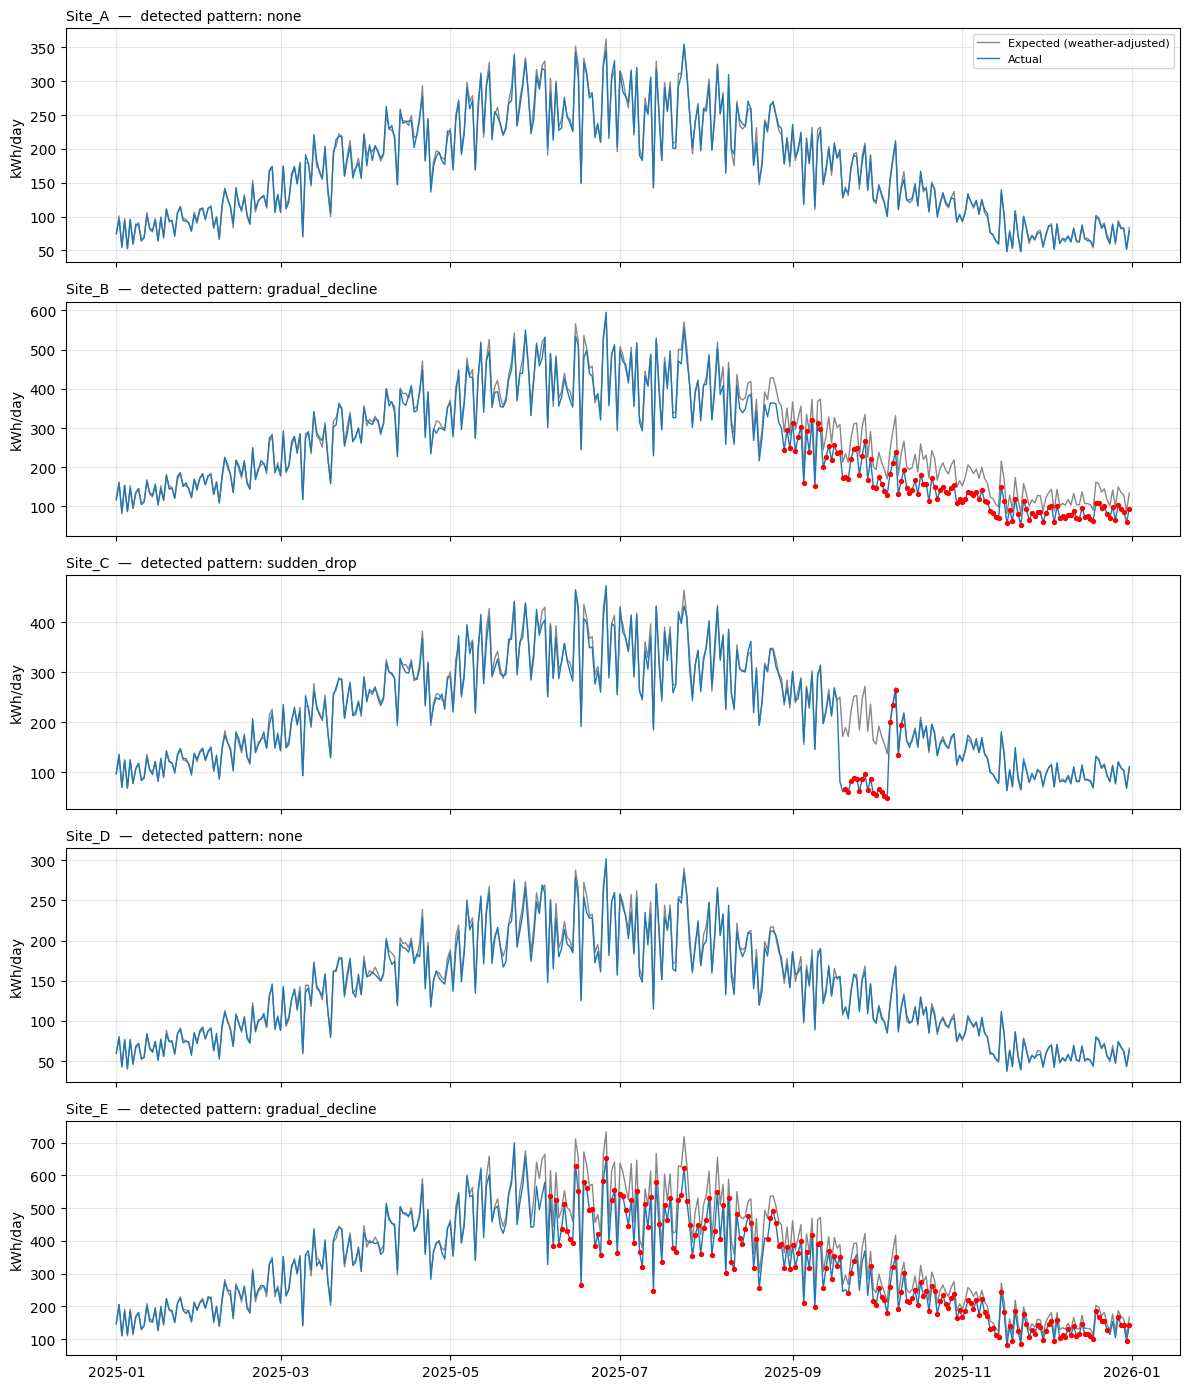

In [30]:

fig, axes = plt.subplots(len(sites), 1, figsize=(12, 14), sharex=True)
for ax, site in zip(axes, sites):
    sub = scored[scored.site == site]
    ax.plot(sub.date, sub.expected_kwh, label='Expected (weather-adjusted)', color='#888', linewidth=1)
    ax.plot(sub.date, sub.actual_kwh, label='Actual', color='#1f77b4', linewidth=1)
    flagged = sub[sub.is_anomaly]
    if not flagged.empty:
        ax.scatter(flagged.date, flagged.actual_kwh, color='red', s=8, zorder=5, label='Flagged')
    ax.set_title(f'{site}  —  detected pattern: {fault_type[site]}', loc='left', fontsize=10)
    ax.set_ylabel('kWh/day')
axes[0].legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('02_expected_vs_actual.png', dpi=110)
plt.show()


## 9. Estimate revenue impact and rank sites needing attention


In [31]:

RATE_PER_KWH = 6  # currency units per kWh, adjust to local tariff

summary_rows = []
for s in sites:
    g = scored[scored.site == s]
    summary_rows.append({
        'site': s,
        'flagged_days': int(g.is_anomaly.sum()),
        'total_shortfall_kwh': -g.loc[g.is_anomaly, 'residual_kwh'].sum(),
        'detected_pattern': fault_type[s],
    })
site_summary = pd.DataFrame(summary_rows)

site_summary['total_shortfall_kwh'] = site_summary['total_shortfall_kwh'].astype(float)
site_summary['estimated_loss'] = (site_summary['total_shortfall_kwh'] * RATE_PER_KWH).round(0)
site_summary = site_summary.sort_values('estimated_loss', ascending=False).reset_index(drop=True)
site_summary['priority_rank'] = site_summary.index + 1

site_summary[['priority_rank', 'site', 'detected_pattern', 'flagged_days', 'total_shortfall_kwh', 'estimated_loss']]


,priority_rank,site,detected_pattern,flagged_days,total_shortfall_kwh,estimated_loss
0,1,Site_E,gradual_decline,197,"9,468.48","56,811.00"
1,2,Site_B,gradual_decline,125,"6,153.33","36,920.00"
2,3,Site_C,sudden_drop,21,"2,074.58","12,447.00"
3,4,Site_A,none,0,-0.00,-0.00
4,5,Site_D,none,0,-0.00,-0.00


## 10. 7-day forward forecast


In [32]:

forecast_rows = []
for site in sites:
    sub = scored[scored.site == site].tail(7)
    weather_next7 = df[df.site == site].tail(7)[['irradiance', 'temperature', 'cloud_cover']]
    forecast_expected = models[site].predict(weather_next7)
    recent_actual_avg = sub['actual_kwh'].mean()
    recent_pct_gap = sub['pct_gap'].mean()
    forecast_rows.append({
        'site': site,
        'forecast_expected_avg_kwh': forecast_expected.mean(),
        'recent_actual_avg_kwh': recent_actual_avg,
        'recent_pct_gap': recent_pct_gap,
        'currently_flagged': bool(sub['is_anomaly'].iloc[-1]),
    })

forecast_df = pd.DataFrame(forecast_rows).sort_values('recent_pct_gap')
forecast_df


,site,forecast_expected_avg_kwh,recent_actual_avg_kwh,recent_pct_gap,currently_flagged
1,Site_B,125.39,86.48,-31.10,True
4,Site_E,156.46,135.71,-13.47,True
3,Site_D,61.59,60.57,-1.53,False
0,Site_A,77.88,76.78,-1.14,False
2,Site_C,100.52,100.02,-0.70,False


## 11. Maintenance-priority dashboard (single summary view)

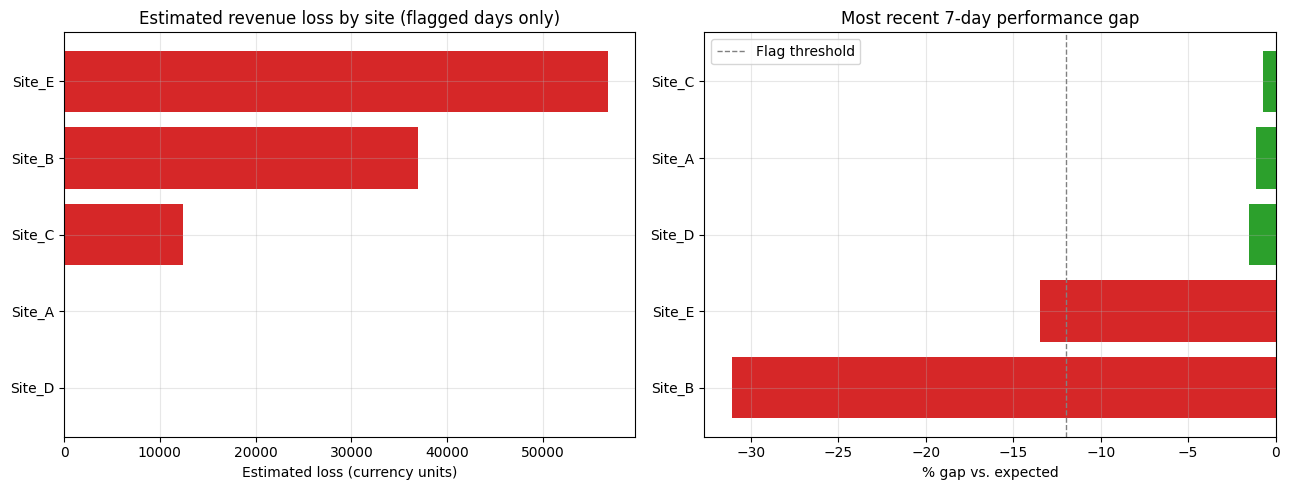

In [33]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#d62728' if p != 'none' else '#2ca02c' for p in site_summary['detected_pattern']]
axes[0].barh(site_summary['site'], site_summary['estimated_loss'], color=colors)
axes[0].invert_yaxis()
axes[0].set_title('Estimated revenue loss by site (flagged days only)')
axes[0].set_xlabel('Estimated loss (currency units)')

axes[1].barh(forecast_df['site'], forecast_df['recent_pct_gap'],
             color=['#d62728' if v < GAP_THRESHOLD else '#2ca02c' for v in forecast_df['recent_pct_gap']])
axes[1].axvline(GAP_THRESHOLD, color='gray', linestyle='--', linewidth=1, label='Flag threshold')
axes[1].set_title('Most recent 7-day performance gap')
axes[1].set_xlabel('% gap vs. expected')
axes[1].legend()

plt.tight_layout()
plt.savefig('03_priority_dashboard.png', dpi=110)
plt.show()
